In [3]:
import pandas as pd
import numpy as np

# 1. Ingest the dataset using relative paths
file_path = '../Data/ds_salaries.csv'
df = pd.read_csv(file_path)

# 2. Complete Task 1 Requirements (Dataset Size and Feature Types)
print(" Task 1: Dataset Verification ")
print(f"Total Database Entries: {df.shape[0]}")
print(f"Total Structural Features: {df.shape[1]}\n")

print(" Structural Feature Data Types ")
df.info()

print("\n Visual Data Sample ")
display(df.head())

 Task 1: Dataset Verification 
Total Database Entries: 607
Total Structural Features: 12

 Structural Feature Data Types 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB

 Visual Data Sample 


,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [4]:
print(f"Shape before cleaning: {df.shape}")

Shape before cleaning: (607, 12)


In [6]:
# chack for 'unnamed: 0' column
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
    print("Dropped 'Unnamed: 0' column.")

In [9]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True) # for missing values


In [11]:
# drop salary_currency and salary if exist
columns_to_drop = ['salary_currency', 'salary']
existing_cols_to_drop = [col for col in columns_to_drop if col in df.columns]
if existing_cols_to_drop:
    df.drop(columns=existing_cols_to_drop, inplace=True)

# after cleaning
print(f"Shape after cleaning: {df.shape}")
    

Shape after cleaning: (565, 9)


In [ ]:
# EDA (Advanced Data Analysis and Visualization)
# 1. Calculate basic statistical summaries for numerical columns
print("1. Statistical Summary of Numerical Columns ")
print(df.describe())
print("\n" + "="*50 + "\n")

# 2. Average salary_in_usd grouped by experience_level (sorted highest to lowest)
print("2. Average Salary (USD) by Experience Level ")
avg_salary_by_exp = df.groupby('experience_level')['salary_in_usd'].mean().sort_values(ascending=False)

# Formatting to display as currency for readability, if desired:
# print(avg_salary_by_exp.apply(lambda x: f"${x:,.2f}"))
print(avg_salary_by_exp)
print("\n" + "="*50 + "\n")

# 3. Top 10 most frequent job titles
print("3. Top 10 Most Frequent Job Titles ")
top_10_job_titles = df['job_title'].value_counts().head(10)
print(top_10_job_titles)
print("\n" + "="*50 + "\n")

# 4. Compare average salary_in_usd between fully remote and fully in-person roles
print("4. Average Salary (USD): Fully Remote vs Fully In-Person ")
# Check if there are any records matching the criteria to avoid calculating mean on empty slices
remote_df = df[df['remote_ratio'] == 100]
in_person_df = df[df['remote_ratio'] == 0]

remote_avg = remote_df['salary_in_usd'].mean() if not remote_df.empty else 0
in_person_avg = in_person_df['salary_in_usd'].mean() if not in_person_df.empty else 0

print(f"Fully Remote (remote_ratio == 100): ${remote_avg:,.2f}")
print(f"Fully In-Person (remote_ratio == 0):  ${in_person_avg:,.2f}")
print("\n" + "="*50 + "\n")


1. Statistical Summary of Numerical Columns 
         work_year  salary_in_usd  remote_ratio
count   565.000000     565.000000    565.000000
mean   2021.364602  110610.343363     69.911504
std       0.698138   72280.702792     40.900666
min    2020.000000    2859.000000      0.000000
25%    2021.000000   60757.000000     50.000000
50%    2021.000000  100000.000000    100.000000
75%    2022.000000  150000.000000    100.000000
max    2022.000000  600000.000000    100.000000


2. Average Salary (USD) by Experience Level 
experience_level
EX    199392.038462
SE    138374.880658
MI     87792.995192
EN     61643.318182
Name: salary_in_usd, dtype: float64


3. Top 10 Most Frequent Job Titles 
job_title
Data Scientist                130
Data Engineer                 121
Data Analyst                   82
Machine Learning Engineer      39
Research Scientist             16
Data Science Manager           12
Data Architect                 11
Machine Learning Scientist      8
Big Data Engineer      

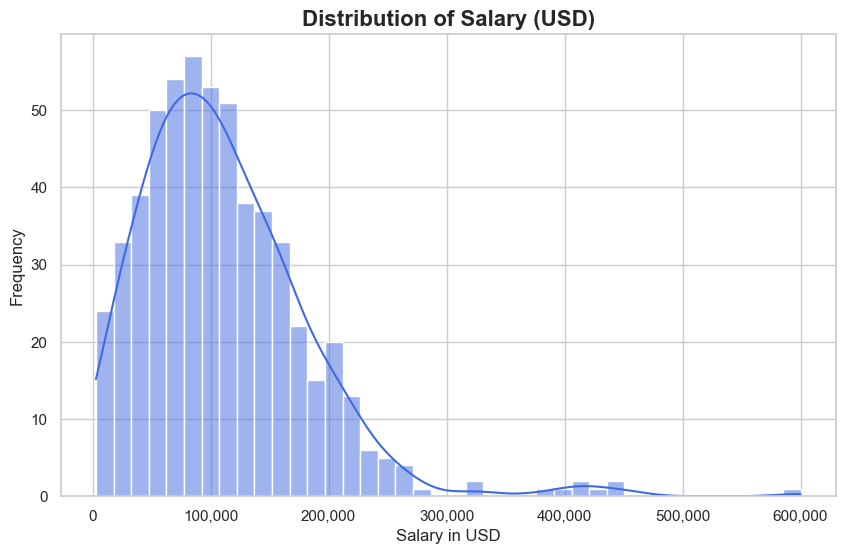

C:\Users\prasi\AppData\Local\Temp\ipykernel_26460\1231528645.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='experience_level', y='salary_in_usd',


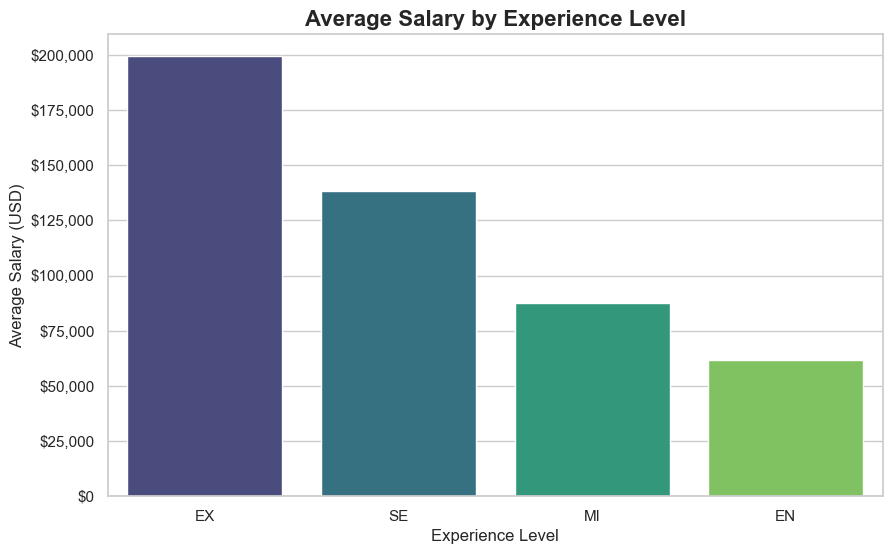

C:\Users\prasi\AppData\Local\Temp\ipykernel_26460\1231528645.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='job_title', order=top_10_jobs, palette='mako')


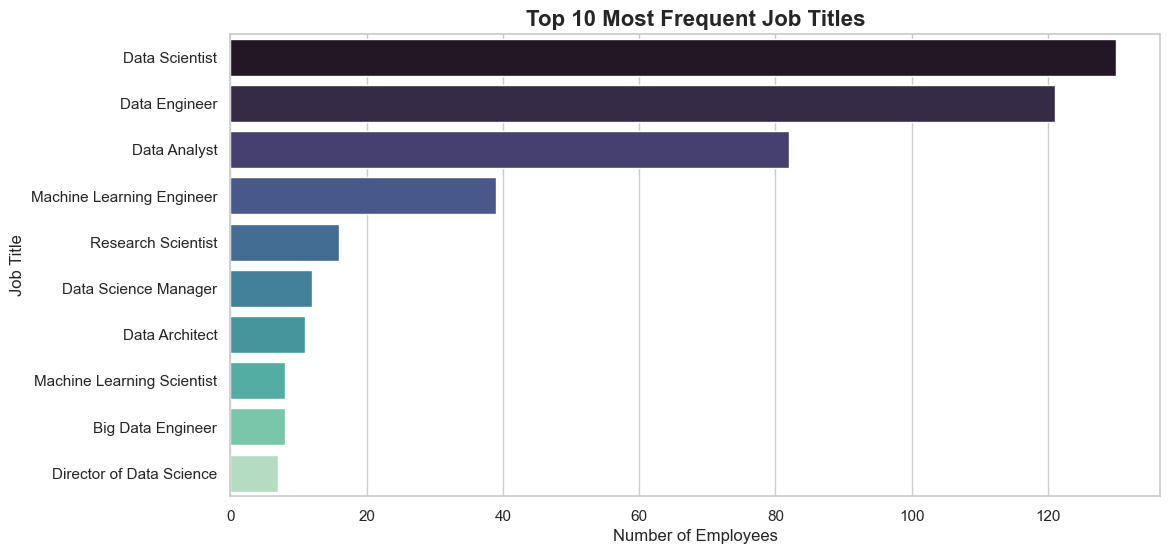

C:\Users\prasi\AppData\Local\Temp\ipykernel_26460\1231528645.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_df, x='Work Arrangement', y='salary_in_usd', palette='Set2')


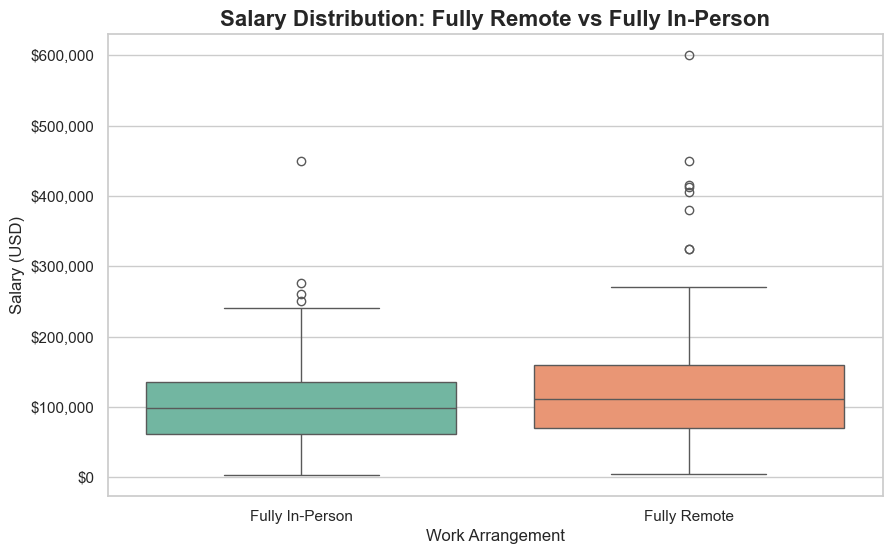

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a cohesive aesthetic theme for the plots
sns.set_theme(style="whitegrid")

# 1. Distribution of Salary in USD
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='salary_in_usd', kde=True, bins=40, color='royalblue')
plt.title('Distribution of Salary (USD)', fontsize=16, fontweight='bold')
plt.xlabel('Salary in USD', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
# Format x-axis with comma separators for currency
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

# 2. Average Salary by Experience Level
plt.figure(figsize=(10, 6))
# Calculate the order based on highest average salary
exp_order = df.groupby('experience_level')['salary_in_usd'].mean().sort_values(ascending=False).index

sns.barplot(data=df, x='experience_level', y='salary_in_usd', 
            order=exp_order, palette='viridis', errorbar=None)
plt.title('Average Salary by Experience Level', fontsize=16, fontweight='bold')
plt.xlabel('Experience Level', fontsize=12)
plt.ylabel('Average Salary (USD)', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('${x:,.0f}'))
plt.show()

# 3. Top 10 Most Frequent Job Titles
plt.figure(figsize=(12, 6))
top_10_jobs = df['job_title'].value_counts().head(10).index

sns.countplot(data=df, y='job_title', order=top_10_jobs, palette='mako')
plt.title('Top 10 Most Frequent Job Titles', fontsize=16, fontweight='bold')
plt.xlabel('Number of Employees', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.show()

# 4. Salary Comparison: Fully Remote vs Fully In-Person (Boxplot)
plt.figure(figsize=(10, 6))
# Filter the dataframe for only fully remote (100) and fully in-person (0)
filtered_df = df[df['remote_ratio'].isin([0, 100])].copy()
# Create a descriptive column for plotting labels
filtered_df['Work Arrangement'] = filtered_df['remote_ratio'].map({0: 'Fully In-Person', 100: 'Fully Remote'})

sns.boxplot(data=filtered_df, x='Work Arrangement', y='salary_in_usd', palette='Set2')
plt.title('Salary Distribution: Fully Remote vs Fully In-Person', fontsize=16, fontweight='bold')
plt.xlabel('Work Arrangement', fontsize=12)
plt.ylabel('Salary (USD)', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('${x:,.0f}'))
plt.show()


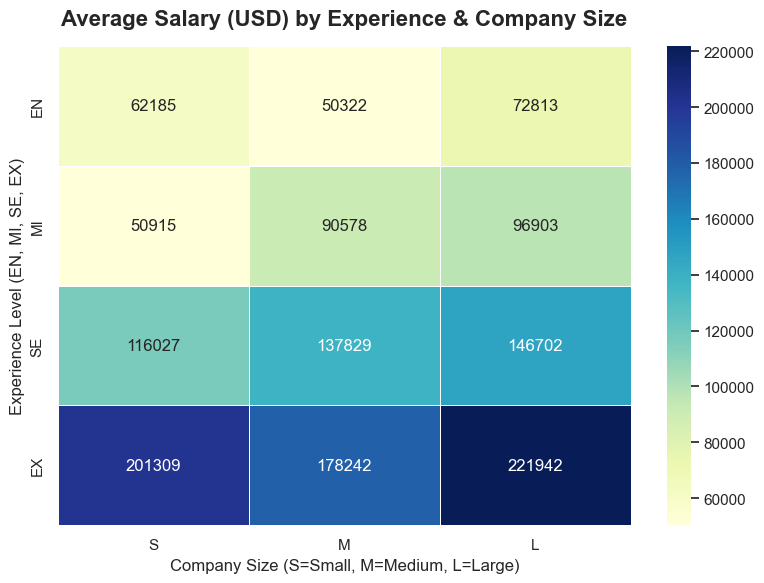

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create the pivot table
heatmap_data = df.pivot_table(
    values='salary_in_usd', 
    index='experience_level', 
    columns='company_size', 
    aggfunc='mean'
)

# 2. Reindex to enforce logical ordering
# Standard Kaggle categories for these fields
exp_order = ['EN', 'MI', 'SE', 'EX']
size_order = ['S', 'M', 'L']

# Safely reindex based only on categories actually present in the dataframe
valid_exp = [x for x in exp_order if x in heatmap_data.index]
valid_size = [x for x in size_order if x in heatmap_data.columns]
heatmap_data = heatmap_data.loc[valid_exp, valid_size]

# 3. Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".0f",           # Displays exact dollar amounts with no decimals
    cmap="YlGnBu",       # A professional, colorblind-friendly palette
    linewidths=0.5       # Adds a clean border between the cells
)

# 4. title and axis labels
plt.title('Average Salary (USD) by Experience & Company Size', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Company Size (S=Small, M=Medium, L=Large)', fontsize=12)
plt.ylabel('Experience Level (EN, MI, SE, EX)', fontsize=12)

# visualization
plt.tight_layout()
plt.show()


In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Select the target (y) and features (X)
y = df['salary_in_usd']
X = df[['experience_level', 'job_title', 'company_size', 'remote_ratio']]

# 2. Convert categorical features into numeric format using one-hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Divide the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 4. Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# 5. Make predictions on the test set
y_pred = rf_model.predict(X_test)

# 6. Evaluate the model using MAE and R-squared
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(" Random Forest Model Evaluation ")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"R-squared (R²) Score: {r2:.4f}")


 Random Forest Model Evaluation 
Mean Absolute Error (MAE): $41,772.96
R-squared (R²) Score: 0.1367


In [20]:
import pandas as pd

def predict_user_salary(trained_model, training_columns):
    """
    Interactively asks the user for candidate details, processes the input, 
    and predicts the salary using the provided machine learning model.
    """
    print(" Enter Candidate Details for Prediction ")
    
    # Collect inputs from the user and format them consistently
    exp_level = input("Enter Experience Level (e.g., EN, MI, SE, EX): ").strip().upper()
    job_title = input("Enter Job Title (e.g., Data Scientist, Data Engineer): ").strip().title()
    comp_size = input("Enter Company Size (e.g., S, M, L): ").strip().upper()
    
    # Safely handle the integer input for remote_ratio
    while True:
        try:
            remote_ratio = int(input("Enter Remote Ratio (0 for in-person, 50 for hybrid, 100 for remote): ").strip())
            break
        except ValueError:
            print("Invalid input. Please enter a valid number (0, 50, or 100).")

    # 1. Create a single-row DataFrame representing the user's input
    user_candidate = pd.DataFrame([{
        'experience_level': exp_level,
        'job_title': job_title,
        'company_size': comp_size,
        'remote_ratio': remote_ratio
    }])

    # 2. Convert categorical text features into numeric format using get_dummies
    user_candidate_encoded = pd.get_dummies(user_candidate)

    # 3. Align the new data's columns with the exact columns the model was trained on
    user_candidate_aligned = user_candidate_encoded.reindex(columns=training_columns, fill_value=0)

    # 4. Predict the salary using the aligned data
    predicted_salary = trained_model.predict(user_candidate_aligned)[0]

    # 5. Your Information
    print("\n Candidate Information ")
    print(f"Experience Level: {exp_level}")
    print(f"Job Title: {job_title}")
    print(f"Company Size: {comp_size}")
    print(f"Remote Ratio: {remote_ratio}")

    # 6. Print the predicted salary cleanly formatted as a dollar amount
    print("\n" + "="*50)
    print(f"Predicted Salary for {exp_level} {job_title}: ${predicted_salary:,.2f}")
    print("="*50 + "\n")

predict_user_salary(rf_model, X_encoded.columns)

 Enter Candidate Details for Prediction 

 Candidate Information 
Experience Level: MI
Job Title: Data Engineer
Company Size: M
Remote Ratio: 0

Predicted Salary for MI Data Engineer: $92,118.18

